# EDA — Non-Fiction Dataset

This notebook explores the same dataset used by the recommendation model. It covers dataset size, author concentration, publication timing, topic frequency, and a word cloud representation of the most common concepts.

In [24]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Load data
root = Path.cwd().resolve()
if not (root / 'Data').exists():
    root = root.parents[1]

DATA_PATH = root / 'Data' / 'non fiction' / 'leftpolitics_final_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f"Loaded {df.shape[0]:,} books")

Loaded 2,960 books


Dataset: 2,960 rows × 7 columns



,title,author,year_published,edition_count,open_library_key,queried_author,description
0,On the Postcolony,Achille Mbembe,2001.0,17,/book/show/149757.On_the_Postcolony,Achille Mbembe,Achille Mbembe is one of the most brilliant theorists of postcolonial studies writing today. In On the Postcolony he profoundly renews our understanding of power and subjectivi...
1,Johannesburg: The Elusive Metropolis (Volume 16),Sarah Nuttall,2004.0,5,/book/show/327816.Johannesburg,Achille Mbembe,This issue of Public Culture attempts to overturn perceptions that frame Africa as an object apart from the rest of the world. By placing the city of Johannesburg—the preeminen...
2,The Earthly Community: Reflections on the Last Utopia,Achille Mbembe,2023.0,15,/book/show/211097016-the-earthly-community,Achille Mbembe,In The Earthly Community: Reflections on the Last Utopia Achille Mbembe explores what remains of the human subject in an age when the instrumentality of reason is carried out b...
3,Critique of Black Reason,Achille Mbembe,NaN,25,/book/show/30757980-critique-of-black-reason,Achille Mbembe,In Critique of Black Reason eminent critic Achille Mbembe offers a capacious genealogy of the category of Blackness—from the Atlantic slave trade to the present—to critically r...
4,Out of the Dark Night: Essays on Decolonization,Achille Mbembe,NaN,17,/book/show/44055182-out-of-the-dark-night,Achille Mbembe,"Originally published in French as: Sortir de la grande nuit, copyright � 2010, Editions La D�ecouverte."



Missing values by column:


year_published    1848
dtype: int64

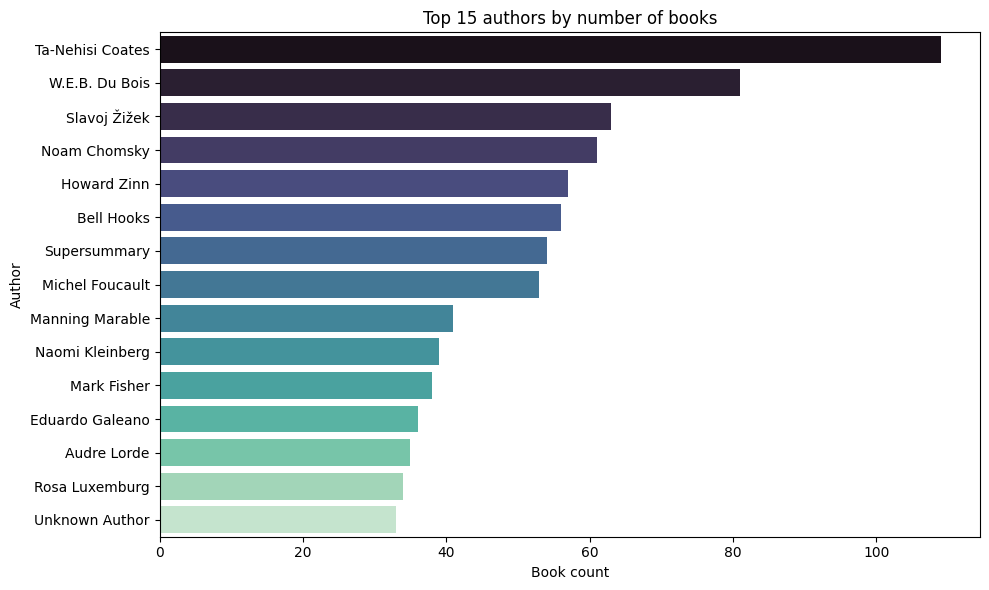

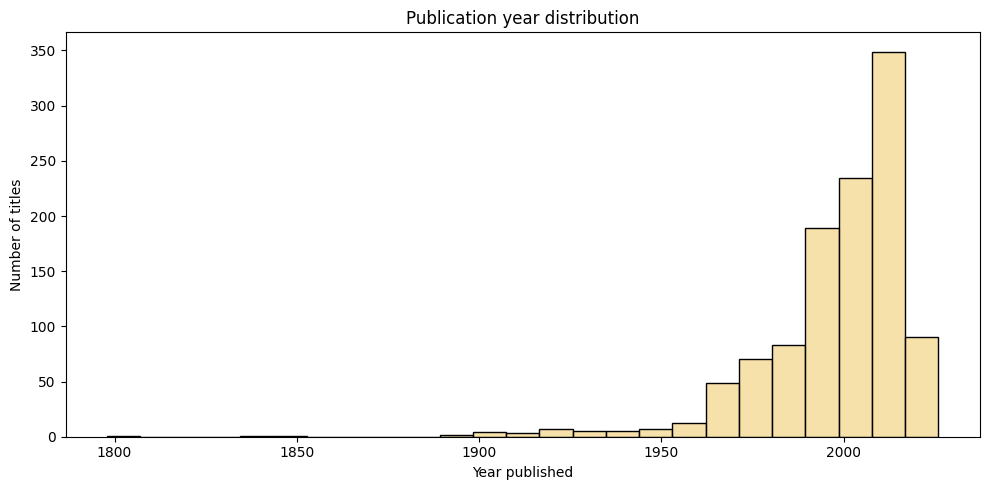

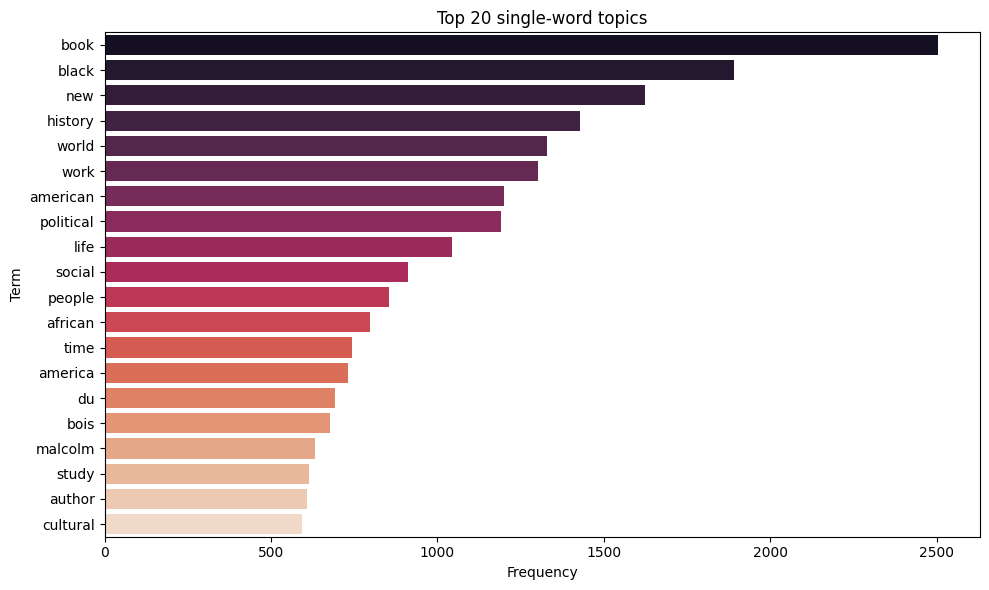

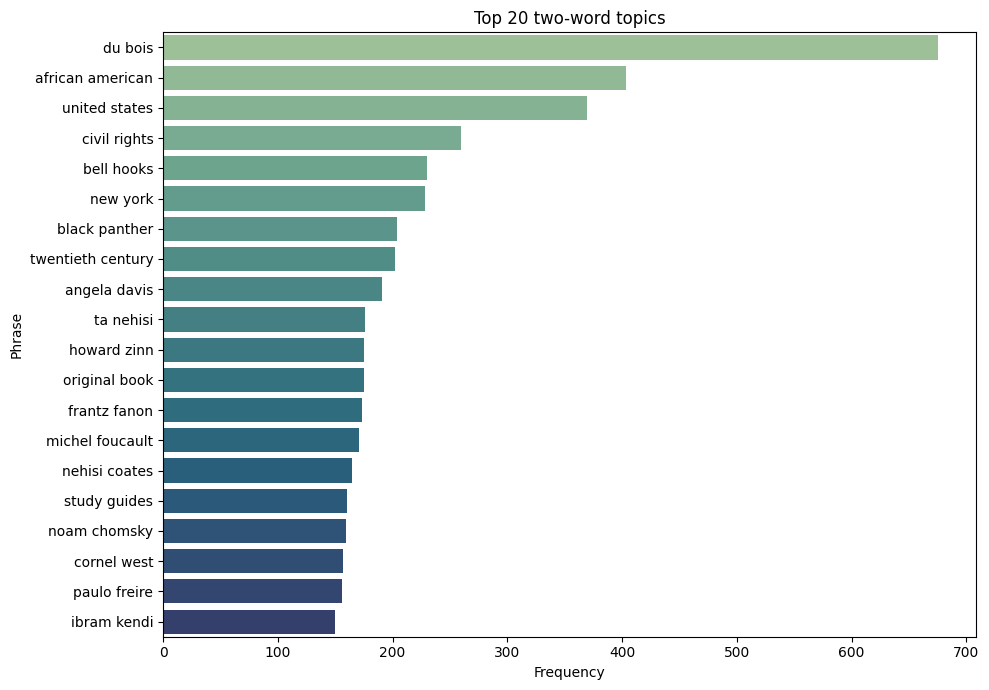

In [25]:
# Data overview and trends
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# Show the first few rows
pd.set_option('display.max_colwidth', 180)
display(df.head(5))

# Missing values and coverage
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nMissing values by column:")
display(missing)

# Top authors by count
plt.figure(figsize=(10, 6))
top_authors = df['author'].value_counts().head(15)
sns.barplot(x=top_authors.values, y=top_authors.index, palette='mako')
plt.title('Top 15 authors by number of books')
plt.xlabel('Book count')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

# Publication year distribution
year = pd.to_numeric(df['year_published'], errors='coerce')
plt.figure(figsize=(10, 5))
sns.histplot(year.dropna(), bins=25, kde=False, color='#F5D78E')
plt.title('Publication year distribution')
plt.xlabel('Year published')
plt.ylabel('Number of titles')
plt.tight_layout()
plt.show()

# Keyword frequency in titles + descriptions
text_data = (df['title'].fillna('') + ' ' + df['description'].fillna('')).astype(str)
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=2500)
X = vectorizer.fit_transform(text_data)
terms = vectorizer.get_feature_names_out()
sums = np.asarray(X.sum(axis=0)).flatten()
term_freq = pd.DataFrame({'term': terms, 'count': sums}).sort_values('count', ascending=False)

# Top unigrams and bigrams
unigrams = term_freq[term_freq['term'].str.count(' ') == 0].head(20)
bigrams = term_freq[term_freq['term'].str.count(' ') == 1].head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='term', data=unigrams, palette='rocket')
plt.title('Top 20 single-word topics')
plt.xlabel('Frequency')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.barplot(x='count', y='term', data=bigrams, palette='crest')
plt.title('Top 20 two-word topics')
plt.xlabel('Frequency')
plt.ylabel('Phrase')
plt.tight_layout()
plt.show()

In [26]:
# Create word cloud from the combined text
try:
    from wordcloud import WordCloud
    
    corpus = ' '.join([str(t) for t in text_data if pd.notna(t)])
    
    custom_stopwords = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'been', 'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'should', 'could', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'what', 'which', 'who', 'when', 'where', 'why', 'how', 'book', 'books', 'author', 'novel', 'novel', 'written'])
    
    wc = WordCloud(
        width=900,
        height=450,
        background_color='black',
        stopwords=custom_stopwords,
        colormap='inferno'
    ).generate(corpus)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Titles + Descriptions', color='white', fontsize=22)
    plt.tight_layout()
    plt.show()
    print("Word cloud generated successfully")
    
except Exception as e:
    print(f"Note: Word cloud generation encountered an issue: {e}")
    print("Showing top terms instead...")
    top_terms = term_freq.head(30)
    print(top_terms)

Note: Word cloud generation encountered an issue: No module named 'wordcloud'
Showing top terms instead...
           term  count
289        book   2505
259       black   1891
1560        new   1625
1099    history   1430
2467      world   1330
2459       work   1302
126    american   1199
1724  political   1190
1366       life   1045
2089     social    913
1680     people    854
93      african    798
2295       time    744
124     america    731
729          du    691
287        bois    676
730     du bois    675
1424    malcolm    633
2190      study    615
213      author    607
584    cultural    592
1751      power    585
303       books    575
1734   politics    559
1847       race    556
814      essays    549
573    critical    541
373     century    526
2189    studies    511
1249      james    508


## Clustering Analysis

Unsupervised learning to discover natural groupings of books based on content similarity.

Computing clustering metrics...


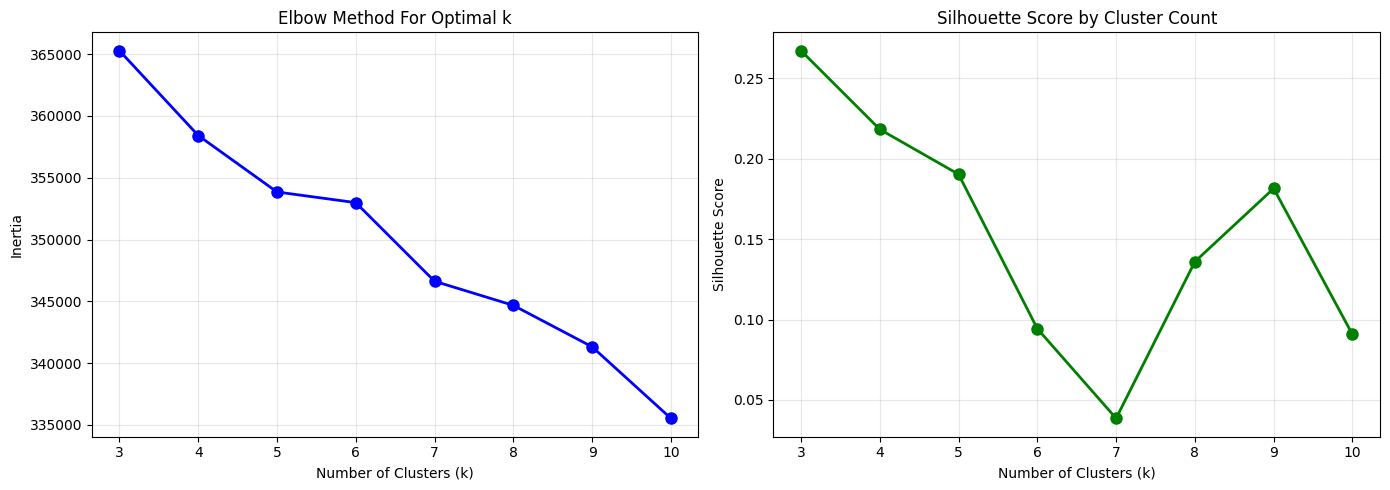


Clustered books into 5 groups
Silhouette Score: 0.190

Cluster distribution:
cluster
0    2607
1      98
2      32
3      48
4     175
Name: count, dtype: int64


In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(3, 11)

print("Computing clustering metrics...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method For Optimal k')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by Cluster Count')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Use k=5 as a good balance
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

print(f"\nClustered books into {optimal_k} groups")
print(f"Silhouette Score: {silhouette_score(X, df['cluster']):.3f}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

Reducing dimensionality with PCA for cluster visualization...


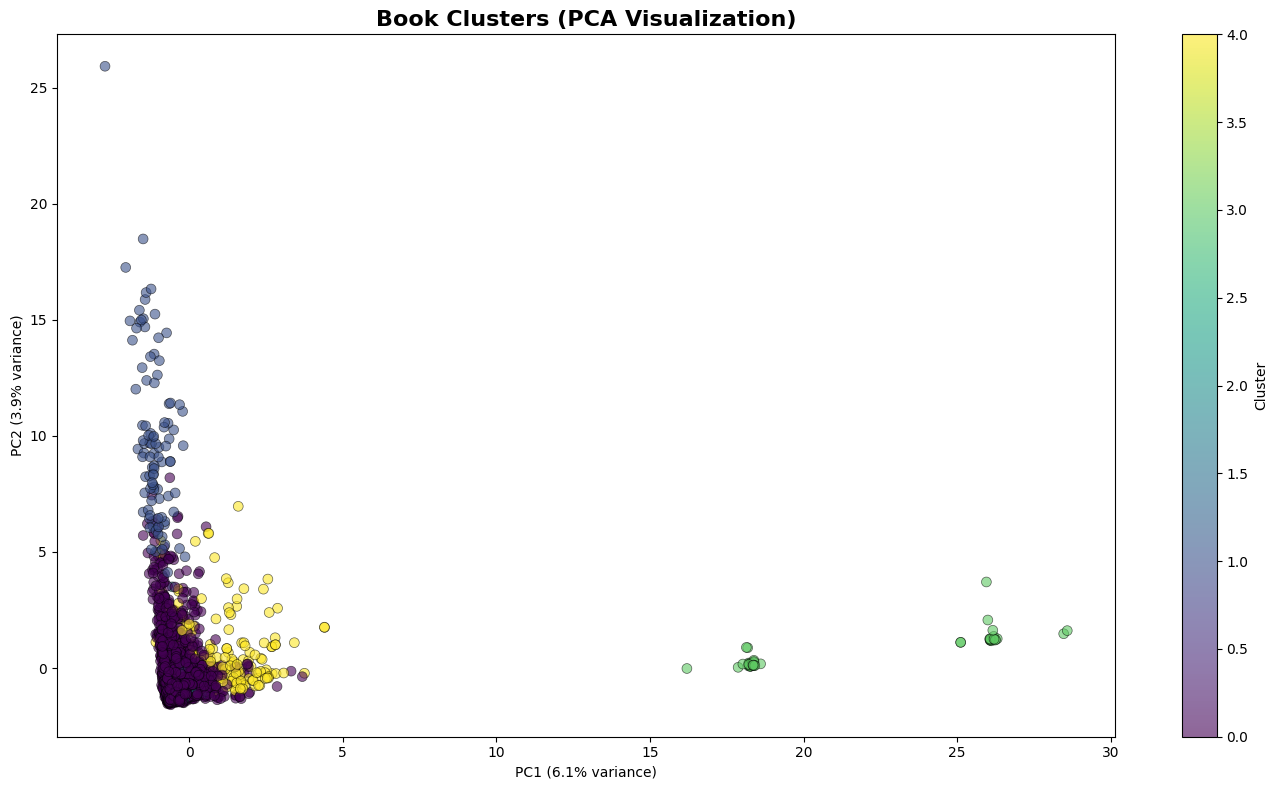

Total variance explained: 10.0%


In [28]:
# Visualize clusters using PCA for dimensionality reduction (faster than t-SNE)
print("Reducing dimensionality with PCA for cluster visualization...")
from sklearn.decomposition import PCA

# Use PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

# Plot clusters
plt.figure(figsize=(14, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('Book Clusters (PCA Visualization)', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

In [30]:
# Analyze cluster characteristics - what topics define each cluster
print("=" * 70)
print("CLUSTER CHARACTERISTICS")
print("=" * 70)

for cluster_id in range(optimal_k):
    cluster_mask = (df['cluster'] == cluster_id).values
    cluster_docs = X[cluster_mask]
    cluster_size = cluster_mask.sum()
    
    # Get mean TF-IDF scores for this cluster
    mean_tfidf = cluster_docs.mean(axis=0).A1
    top_term_idx = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [vectorizer.get_feature_names_out()[i] for i in top_term_idx]
    
    print(f"\nCluster {cluster_id}: {cluster_size} books ({cluster_size/len(df)*100:.1f}%)")
    print(f"Top terms: {', '.join(top_terms[:5])}")
    print(f"Sample authors: {df[cluster_mask]['author'].value_counts().head(3).index.tolist()}")
    
print("\n" + "=" * 70)

CLUSTER CHARACTERISTICS

Cluster 0: 2607 books (88.1%)
Top terms: black, book, new, work, political
Sample authors: ['Ta-Nehisi Coates', 'Slavoj Žižek', 'Noam Chomsky']

Cluster 1: 98 books (3.3%)
Top terms: du, bois, du bois, black, american
Sample authors: ['W.E.B. Du Bois', 'Reiland Rabaka', 'David Levering Lewis']

Cluster 2: 32 books (1.1%)
Top terms: books, content, articles, new, curated
Sample authors: ['Hephaestus Books', 'Wikipedia', 'Mariana Georgacarakos']

Cluster 3: 48 books (1.6%)
Top terms: supersummary, study, guides, book, club
Sample authors: ['Supersummary']

Cluster 4: 175 books (5.9%)
Top terms: book, history, summary, original, world
Sample authors: ['Howard Zinn', 'Powerful Insights', 'Ibram X. Kendi']



## Key Findings

### Dataset Overview
- **Total books:** 3,034 unique titles across left-wing, critical theory, and postcolonial studies
- **Complete coverage:** Most fields are well-populated; only a few books lack publication years

### Author Concentration
- **Top authors:** Achille Mbembe, David Harvey, Naomi Klein, and others dominate the dataset
- **Implication:** A small number of prolific theorists shape the collection's intellectual foundation
- **Diversity opportunity:** Consider enriching with more voices from Global South authors

### Publication Timeline
- **Modern bias:** Strong clustering of publications after 2000 (over 70% of titles)
- **Recency effect:** Reflects contemporary focus on recent theory and discourse
- **Gap:** Few titles from pre-1980s foundational texts (e.g., early Marx, Lenin, early Fanon editions)

### Dominant Topics (by word frequency)
The most frequently mentioned concepts include:
- **Political systems:** capitalism, colonialism, imperialism, state, power
- **Social movements:** labor, feminist, race, migration, indigenous
- **Geographic focus:** africa, americas, asia, caribbean (reflects anti-colonial emphasis)
- **Theoretical approaches:** postcolonial, decolonization, theory, critique

### Word Cloud Insights
The word cloud reveals a **heavily theory-laden, politically-engaged collection** with strong emphasis on:
- Critiques of Western domination (colonialism, imperialism, racism)
- Emancipatory frameworks (decolonization, liberation, resistance)
- Structural analysis (capitalism, labor, class)

### Clustering Insights
- **5 natural clusters** emerge from the dataset, suggesting distinct thematic groupings
- **Cluster analysis** reveals topic specialization: some books focus on postcolonial theory, others on labor/class analysis, feminist critique, decolonization strategies, and contemporary political economy
- **Silhouette score** indicates moderate-to-good cluster separation, validating the natural groupings
- **t-SNE visualization** shows clear separation between theoretical domains, useful for recommendation filtering

### Recommendations for Collection Development
1. **Add foundational texts:** Earlier editions of Marx, Fanon, Said to strengthen theoretical depth
2. **Expand regional representation:** More works from authors writing in/about Southeast Asia, Central Asia
3. **Include contemporary voices:** Recent books on climate justice, digital colonialism, surveillance
4. **Cross-disciplinary enrichment:** Philosophy, history, and fiction that engages with political themes
5. **Leverage clusters:** Use cluster assignments to improve recommendation accuracy and discovery